In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
plt.rcParams["font.size"] = 8
from keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

2024-02-13 15:17:42.701494: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-13 15:17:42.701625: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-13 15:17:42.841823: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
data_dir = Path('/kaggle/input/parkinsons-brain-mri-dataset/parkinsons_dataset')
data_dir

PosixPath('/kaggle/input/parkinsons-brain-mri-dataset/parkinsons_dataset')

In [3]:
df = pd.DataFrame({'path': list(data_dir.glob('*/*.png'))})
df['img_id'] = df['path'].map(lambda x: x.stem)
df['disease'] = df['path'].map(lambda x: x.parent.stem)
print(df.shape, 'images loaded')
df.head()

(831, 3) images loaded


,path,img_id,disease
0,/kaggle/input/parkinsons-brain-mri-dataset/par...,mIP_Images(SW)_027,normal
1,/kaggle/input/parkinsons-brain-mri-dataset/par...,Pha_Images_059,normal
2,/kaggle/input/parkinsons-brain-mri-dataset/par...,t1_fl3d_sag_p4_iso_1.0_002,normal
3,/kaggle/input/parkinsons-brain-mri-dataset/par...,ep2d_diff_3scan_trace_p2_TRACEW_DFC_010,normal
4,/kaggle/input/parkinsons-brain-mri-dataset/par...,t2_tirm_tra_dark-fluid_007,normal


In [4]:
df['path'] = df['path'].apply(lambda x: Path(x))

def extract_prefix(file_path):
    prefix = file_path.stem.rsplit('_', 1)[0]
    return prefix

df['label'] = df['path'].apply(extract_prefix)
df

,path,img_id,disease,label
0,/kaggle/input/parkinsons-brain-mri-dataset/par...,mIP_Images(SW)_027,normal,mIP_Images(SW)
1,/kaggle/input/parkinsons-brain-mri-dataset/par...,Pha_Images_059,normal,Pha_Images
2,/kaggle/input/parkinsons-brain-mri-dataset/par...,t1_fl3d_sag_p4_iso_1.0_002,normal,t1_fl3d_sag_p4_iso_1.0
3,/kaggle/input/parkinsons-brain-mri-dataset/par...,ep2d_diff_3scan_trace_p2_TRACEW_DFC_010,normal,ep2d_diff_3scan_trace_p2_TRACEW_DFC
4,/kaggle/input/parkinsons-brain-mri-dataset/par...,t2_tirm_tra_dark-fluid_007,normal,t2_tirm_tra_dark-fluid
...,...,...,...,...
826,/kaggle/input/parkinsons-brain-mri-dataset/par...,sDW_SSh_031,parkinson,sDW_SSh
827,/kaggle/input/parkinsons-brain-mri-dataset/par...,DUAL_TSE_028,parkinson,DUAL_TSE
828,/kaggle/input/parkinsons-brain-mri-dataset/par...,T1W_FFE_002,parkinson,T1W_FFE
829,/kaggle/input/parkinsons-brain-mri-dataset/par...,sDW_SSh_044,parkinson,sDW_SSh


In [5]:
df['label'].value_counts()

label
t1_fl3d_sag_p4_iso_1.0                 176
Pha_Images                              72
Mag_Images                              72
SWI_Images                              72
mIP_Images(SW)                          65
ep2d_diff_3scan_trace_p2_TRACEW_DFC     60
Reg_-_sDW_SSh_SENSE                     44
sDW_SSh                                 44
DUAL_TSE                                44
t2_tirm_tra_dark-fluid                  30
t2_tse_tra                              30
ep2d_diff_3scan_trace_p2_ADC_DFC        30
T2W_FLAIR                               22
T1W_FFE                                 22
dReg_-_sDW_SSh_SENSE                    22
T2W_TSE                                 18
Survey_SHC                               5
localizer                                3
Name: count, dtype: int64

In [6]:
df.nunique()

path       831
img_id     831
disease      2
label       18
dtype: int64

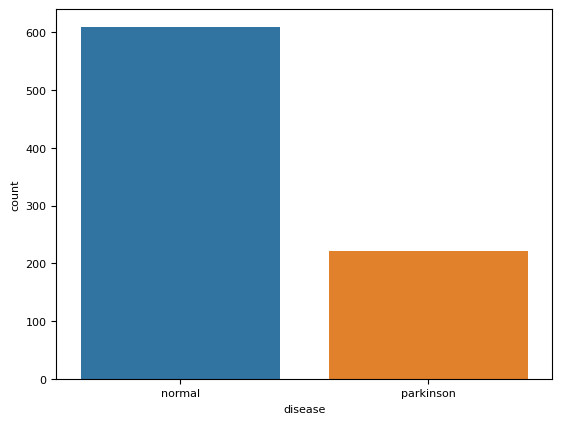

In [7]:
sns.countplot(df, x='disease')
plt.show()

## TRAIN TEST SPLIT

In [8]:
from sklearn.model_selection import train_test_split

X = df['path']
y = df['disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(664,) (664,)
(167,) (167,)


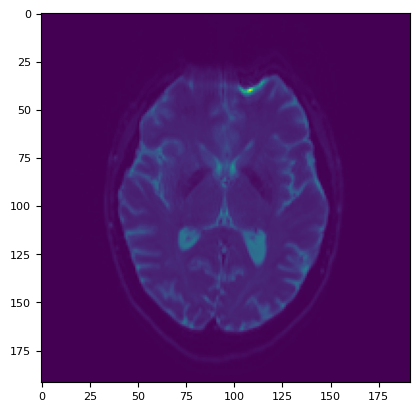

(192, 192)

In [10]:
image = plt.imread(X_train.iloc[1])
plt.imshow(image)
plt.show()

image.shape

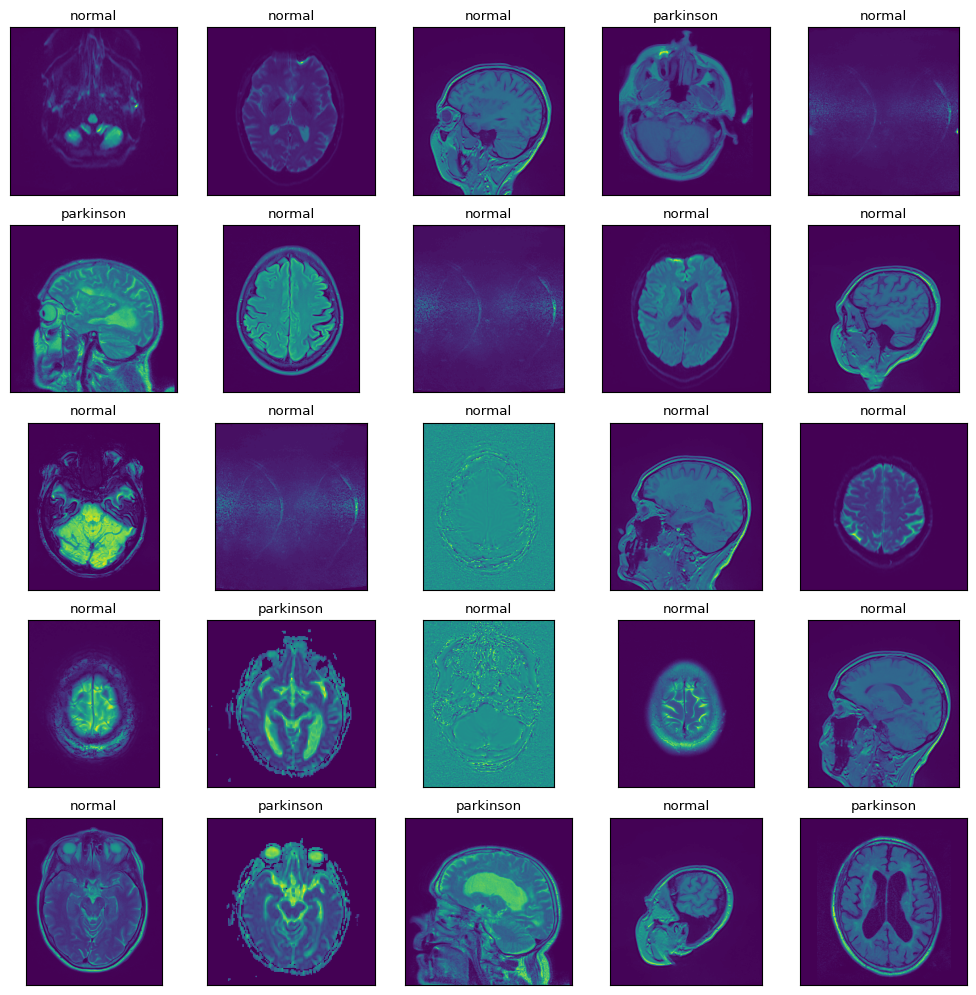

In [11]:
fig, axes = plt.subplots(nrows=5,
                        ncols=5,
                        figsize=(10,10),
                        subplot_kw={"xticks":[],"yticks":[]})

for i,ax in enumerate(axes.flat):
    ax.imshow(plt.imread(X_train.iloc[i]))
    ax.set_title(y_train.iloc[i])
plt.tight_layout()
plt.show()

## TrainDATA

In [12]:
trainData = pd.DataFrame({'path':X_train, 'disease':y_train})
trainData.loc[:, 'path'] = trainData['path'].astype(str)

# train_datagen = ImageDataGenerator(rescale=1./255)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
# 
train_generator = train_datagen.flow_from_dataframe(
    dataframe=trainData,
    x_col='path',         
    y_col='disease',      
    target_size=(224, 224), 
    batch_size=32,        
    class_mode='binary'
)

Found 664 validated image filenames belonging to 2 classes.


## TestDATA

In [13]:
testData = pd.DataFrame({'path':X_test, 'disease':y_test})
testData.loc[:, 'path'] = testData['path'].astype(str)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=testData,
    x_col='path',         
    y_col='disease',      
    target_size=(224, 224), 
    batch_size=32,        
    class_mode='binary'
)

Found 167 validated image filenames belonging to 2 classes.


# MODEL TRAINING

In [14]:
def loss_history_plot(history):
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title("Model Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title("Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

In [15]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.models import Model, Sequential

from tensorflow.keras.optimizers import Adam

In [16]:
def train_model(base_model):
    for layer in base_model.layers[:-5]:
            layer.trainable = False
    
    top_model = base_model.output
    top_model = Flatten(name="flatten")(top_model)
#     top_model = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(top_model)
    top_model = Dropout(0.5)(top_model)
    output_layer = Dense(1, activation='sigmoid')(top_model)
    model = Model(inputs=base_model.input, outputs=output_layer)
    
    
#     new_learning_rate = 0.0001 
#     custom_optimizer = Adam(learning_rate=new_learning_rate)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    
    history = model.fit(train_generator, epochs=25, validation_data=test_generator, batch_size = 32)
    
    return model, history

# VGG 16

In [17]:
from keras.applications import VGG16
from tensorflow.keras import regularizers

In [18]:
VGG = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

58889256/58889256 [==============================] - 0s 0us/step


In [19]:
model, history = train_model(VGG)

Epoch 1/25


I0000 00:00:1707837488.441263      72 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


21/21 [==============================] - 26s 780ms/step - loss: 0.9188 - accuracy: 0.6687 - val_loss: 5668.4282 - val_accuracy: 0.6707
Epoch 2/25
21/21 [==============================] - 9s 407ms/step - loss: 0.5901 - accuracy: 0.7364 - val_loss: 3988.4194 - val_accuracy: 0.6707
Epoch 3/25
21/21 [==============================] - 8s 387ms/step - loss: 0.5945 - accuracy: 0.7364 - val_loss: 558.0273 - val_accuracy: 0.6707
Epoch 4/25
21/21 [==============================] - 8s 383ms/step - loss: 0.5352 - accuracy: 0.7530 - val_loss: 1105.8135 - val_accuracy: 0.6707
Epoch 5/25
21/21 [==============================] - 8s 390ms/step - loss: 0.4799 - accuracy: 0.7696 - val_loss: 1107.5703 - val_accuracy: 0.8323
Epoch 6/25
21/21 [==============================] - 8s 395ms/step - loss: 0.4018 - accuracy: 0.8343 - val_loss: 1004.7553 - val_accuracy: 0.8383
Epoch 7/25
21/21 [==============================] - 8s 382ms/step - loss: 0.9667 - accuracy: 0.8870 - val_loss: 421.8219 - val_accuracy: 0.89

In [20]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [21]:
predictions = model.predict(test_generator)
predictions = [1 if x>0.5 else 0 for x in predictions]
true_labels = test_generator.classes
confusion_mtx = confusion_matrix(true_labels, predictions) 
confusion_mtx

6/6 [==============================] - 1s 80ms/step


array([[73, 39],
       [33, 22]])

In [22]:
accuracy = accuracy_score(true_labels, predictions)
print('Val Accuracy = %.2f' % accuracy)

Val Accuracy = 0.57


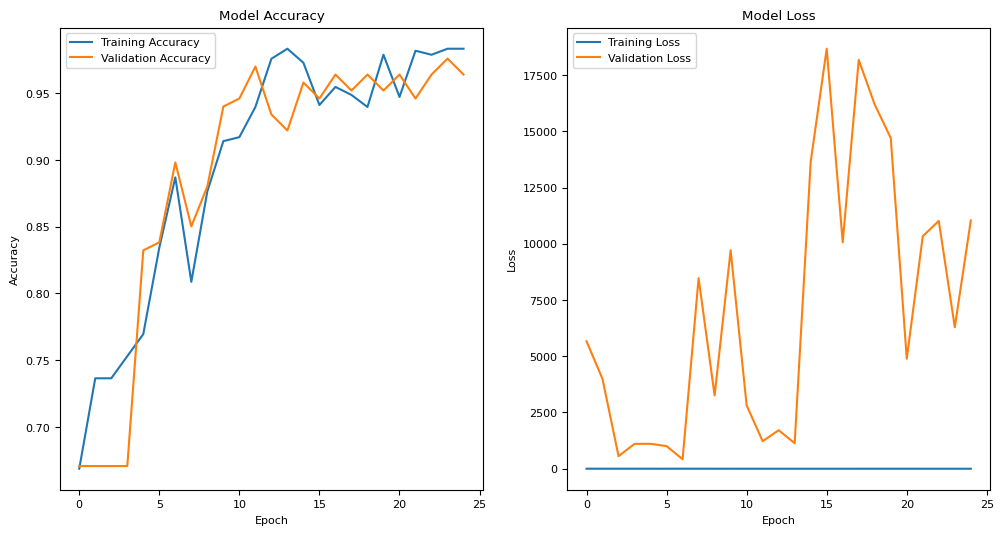

In [23]:
loss_history_plot(history)

# RESNET50

In [24]:
from keras.applications import ResNet50

In [25]:
resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


94765736/94765736 [==============================] - 1s 0us/step


In [26]:
model, history = train_model(resnet)

Epoch 1/25
21/21 [==============================] - 15s 443ms/step - loss: 2.6082 - accuracy: 0.6627 - val_loss: 5.8779 - val_accuracy: 0.6707
Epoch 2/25
21/21 [==============================] - 8s 388ms/step - loss: 1.0992 - accuracy: 0.6988 - val_loss: 11.5622 - val_accuracy: 0.6707
Epoch 3/25
21/21 [==============================] - 8s 385ms/step - loss: 0.8295 - accuracy: 0.7425 - val_loss: 8.0496 - val_accuracy: 0.6707
Epoch 4/25
21/21 [==============================] - 8s 400ms/step - loss: 0.5354 - accuracy: 0.7560 - val_loss: 6.4155 - val_accuracy: 0.6766
Epoch 5/25
21/21 [==============================] - 8s 400ms/step - loss: 0.5172 - accuracy: 0.7786 - val_loss: 4.1633 - val_accuracy: 0.6826
Epoch 6/25
21/21 [==============================] - 8s 384ms/step - loss: 0.4075 - accuracy: 0.8298 - val_loss: 3.2997 - val_accuracy: 0.6886
Epoch 7/25
21/21 [==============================] - 8s 383ms/step - loss: 0.4466 - accuracy: 0.8057 - val_loss: 2.4090 - val_accuracy: 0.7066
Epoc

In [27]:
predictions = model.predict(test_generator)
predictions = [1 if x>0.5 else 0 for x in predictions]
true_labels = test_generator.classes

confusion_mtx = confusion_matrix(true_labels, predictions) 
confusion_mtx

6/6 [==============================] - 1s 81ms/step


array([[98, 14],
       [51,  4]])

In [28]:
accuracy = accuracy_score(true_labels, predictions)
print('Val Accuracy = %.2f' % accuracy)

Val Accuracy = 0.61


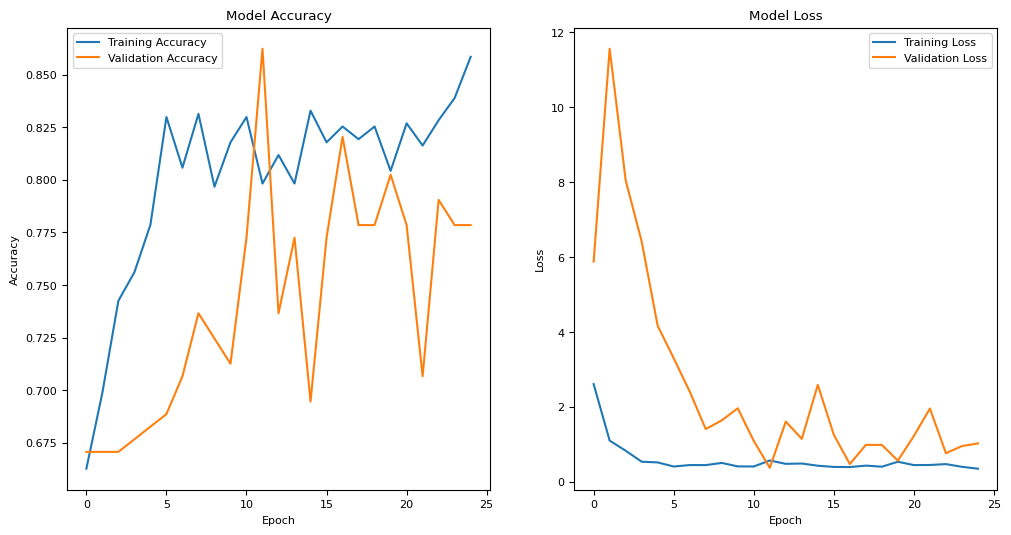

In [29]:
loss_history_plot(history)

# InceptionV3

In [30]:
from keras.applications import InceptionV3

In [31]:
inception = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

87910968/87910968 [==============================] - 0s 0us/step


In [32]:
model, history = train_model(inception)

Epoch 1/25
21/21 [==============================] - 18s 548ms/step - loss: 1.8704 - accuracy: 0.7048 - val_loss: 1.2736 - val_accuracy: 0.7784
Epoch 2/25
21/21 [==============================] - 8s 393ms/step - loss: 0.4126 - accuracy: 0.8825 - val_loss: 0.2552 - val_accuracy: 0.9281
Epoch 3/25
21/21 [==============================] - 8s 387ms/step - loss: 0.2695 - accuracy: 0.9111 - val_loss: 0.0841 - val_accuracy: 0.9641
Epoch 4/25
21/21 [==============================] - 8s 378ms/step - loss: 0.1387 - accuracy: 0.9488 - val_loss: 0.1184 - val_accuracy: 0.9581
Epoch 5/25
21/21 [==============================] - 8s 390ms/step - loss: 0.2691 - accuracy: 0.9066 - val_loss: 0.0347 - val_accuracy: 0.9820
Epoch 6/25
21/21 [==============================] - 8s 395ms/step - loss: 0.1729 - accuracy: 0.9443 - val_loss: 0.0528 - val_accuracy: 0.9820
Epoch 7/25
21/21 [==============================] - 8s 391ms/step - loss: 0.1089 - accuracy: 0.9669 - val_loss: 0.0414 - val_accuracy: 0.9701
Epoch

In [33]:
predictions = model.predict(test_generator)
predictions = [1 if x>0.5 else 0 for x in predictions]
true_labels = test_generator.classes

confusion_mtx = confusion_matrix(true_labels, predictions) 
confusion_mtx

6/6 [==============================] - 2s 83ms/step


array([[71, 41],
       [41, 14]])

In [34]:
accuracy = accuracy_score(true_labels, predictions)
print('Val Accuracy = %.2f' % accuracy)

Val Accuracy = 0.51


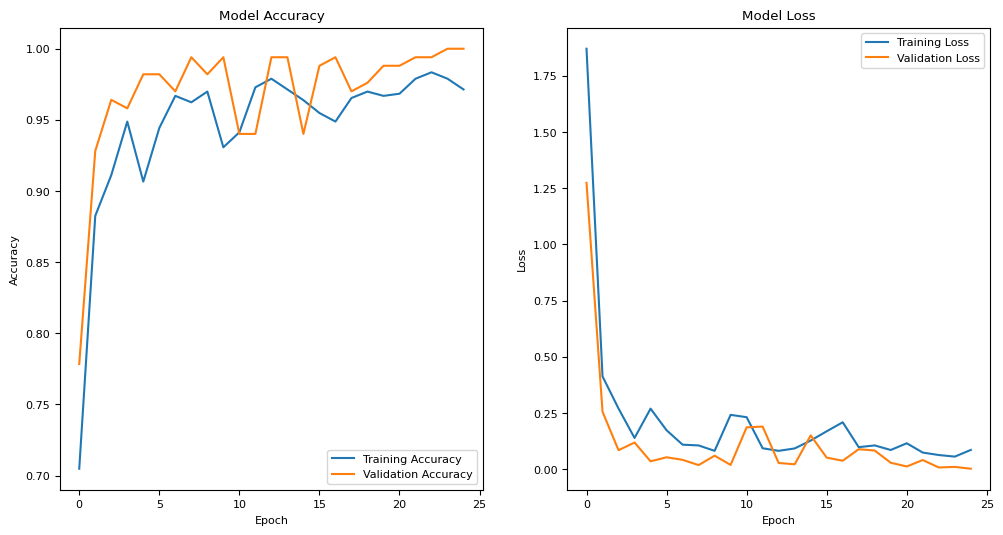

In [35]:
loss_history_plot(history)

# Xception

# MobileNetV2